## Load libraries and set project directory

In [1]:
# Load libraries
import pandas as pd
import gseapy as gp
from gseapy import barplot, dotplot, heatmap
from gseapy import Msigdb
import matplotlib.pyplot as plt
import os
import numpy as np
import statsmodels.stats.multitest
#.stats.multitest.fdrcorrection(pvals, alpha=0.05, method='indep', is_sorted=False)[source]
import seaborn as sns
import statsmodels.api as sm
from statsmodels.stats.weightstats import ttest_ind
import networkx as nx
import random
from sklearn import linear_model
from sklearn import linear_model
import scipy
from scipy.cluster.hierarchy import dendrogram, linkage
from scipy.cluster.hierarchy import cophenet
from scipy.spatial.distance import pdist
%matplotlib inline

# Set project directory as working directory
project_dir = "/lab-share/Pulmonary-Chun-e2/Public/data/czi_integration"
os.chdir(project_dir)

# Prep data

## Read in differential gene list

The differential genes are comparing in NPC2 vs Control samples for both AT2 cells and macrophage cells.

In [2]:
# Read in data
de_genes_at2 = pd.read_csv("output/08_de_at2_vs_ctrl.csv")
de_genes_macs = pd.read_csv("output/08_de_macs_vs_ctrl.csv")

de_genes_at2.columns.values[0] = "gene_symbol"
de_genes_macs.columns.values[0] = "gene_symbol"

print(de_genes_at2.head())
print(de_genes_macs.head())

  gene_symbol          p_val  avg_log2FC  pct.1  pct.2      p_val_adj
0       DTHD1  8.825132e-278   -3.656918  0.306  0.104  1.544398e-274
1      LMNTD1  1.879619e-219   -1.045546  0.427  0.192  3.289333e-216
2    KIAA1211  3.240984e-183   -8.585989  0.622  0.333  5.671722e-180
3       CHST9  1.870905e-166   -4.316990  0.415  0.212  3.274084e-163
4    CABCOCO1  2.251106e-158   -0.104351  0.335  0.157  3.939435e-155
  gene_symbol          p_val  avg_log2FC  pct.1  pct.2      p_val_adj
0   MTRNR2L12   0.000000e+00    4.192338  0.756  0.088   0.000000e+00
1        XIST   0.000000e+00  -12.668980  0.000  0.642   0.000000e+00
2      HS3ST2   0.000000e+00    5.056330  0.514  0.014   0.000000e+00
3      TCF7L2  1.615220e-264   -3.323688  0.319  0.792  5.066784e-260
4      FNDC3B  1.311863e-256   -1.922318  0.712  0.932  4.115185e-252


## Filter data

In [3]:
# Process data
de_genes_at2 = de_genes_at2[de_genes_at2["gene_symbol"] != "-"]  # remove genes with missing symbols
de_genes_at2 = de_genes_at2[de_genes_at2["p_val_adj"].notna()] # remove genes with missing pvalues

de_genes_macs = de_genes_macs[de_genes_macs["gene_symbol"] != "-"]  # remove genes with missing symbols
de_genes_macs = de_genes_macs[de_genes_macs["p_val_adj"].notna()] # remove genes with missing pvalues

# Filter to DE genes with a adjusted p-value < 0.05 and 0.01
## AT2
padj01de_genes_at2 = de_genes_at2[de_genes_at2["p_val_adj"] < 0.1]
padj005de_genes_at2 = de_genes_at2[de_genes_at2["p_val_adj"] < 0.05]

print(len(padj01de_genes_at2))
print(len(padj005de_genes_at2))

## Macrophages
padj01de_genes_macs = de_genes_macs[de_genes_macs["p_val_adj"] < 0.1]
padj005de_genes_macs = de_genes_macs[de_genes_macs["p_val_adj"] < 0.05]

print(len(padj01de_genes_macs))
print(len(padj005de_genes_macs))

922
895
4993
4808


## Rank genes by log2 fold change

You need to separate by positive and negative because positive log2fc gets a positive score and vice versa and then the two separated rankings get combined.
The bigger the absolute value of the ranking, the bigger absolute value fo the log2fc.

### AT2 Cells

In [4]:
# Sort by log2fc
de_genes_at2 = de_genes_at2.sort_values("avg_log2FC", ascending = False)

# Split into positive and negative log2fc, rank accordingly
num_pos_genes_at2 = len(de_genes_at2[de_genes_at2["avg_log2FC"] >= 0])
num_list_positive_log2fc_at2 = list(range(num_pos_genes_at2, 0, -1))
num_neg_genes_at2 = len(de_genes_at2[de_genes_at2["avg_log2FC"] < 0])
num_list_negative_log2fc_at2 = list(range(-1, -1 * (num_neg_genes_at2 + 1), -1))

# Add ranks to dataframe
log2fc_ranks = num_list_positive_log2fc_at2 + num_list_negative_log2fc_at2
de_genes_at2["log2fc_ranks"] = log2fc_ranks

### Macrophage Cells

In [5]:
# Sort by log2fc
de_genes_macs = de_genes_macs.sort_values("avg_log2FC", ascending = False)

# Split into positive and negative log2fc, rank accordingly
num_pos_genes_macs = len(de_genes_macs[de_genes_macs["avg_log2FC"] >= 0])
num_list_positive_log2fc_macs = list(range(num_pos_genes_macs, 0, -1))
num_neg_genes_macs = len(de_genes_macs[de_genes_macs["avg_log2FC"] < 0])
num_list_negative_log2fc_macs = list(range(-1, -1 * (num_neg_genes_macs + 1), -1))

# Add ranks to dataframe
log2fc_ranks = num_list_positive_log2fc_macs + num_list_negative_log2fc_macs
de_genes_macs["log2fc_ranks"] = log2fc_ranks

## Rank genes by p-value

Again you have to separate by positive and negative log2fc for the same reasons as above.

You have to use regular p-value instead of adjusted p-value because the adjusted p-value will give less ties; this is especially important for Wilcoxon rank sum tests.

### AT2 Cells

In [6]:
# Transform p-values into -log(pvalues) for easier sorting (more significant genes will have bigger numbers)
minus_log_pval_at2 = list(-np.log10(de_genes_at2["p_val"].tolist()))
de_genes_at2["minus_log10_p_val"] = minus_log_pval_at2

# Sort by p-value
de_genes_at2 = de_genes_at2.sort_values("minus_log10_p_val", ascending = False)

Now that the genes are sorted, we can split them into positive and negative, rank, and then recombine the rankings.

In [7]:
# Split into positive and negative log2fc and rank according to -log(pvalue)
pos_log2fc_at2 = de_genes_at2[de_genes_at2["avg_log2FC"] >= 0]
pos_log2fc_at2["pval_ranks"] = num_list_positive_log2fc_at2 # List already defined above in log2fc ranking step


neg_log2fc_at2 = de_genes_at2[de_genes_at2["avg_log2FC"] < 0]
neg_log2fc_at2 = neg_log2fc_at2.sort_values("minus_log10_p_val", ascending = True)
neg_log2fc_at2["pval_ranks"] = num_list_negative_log2fc_at2

# Add ranks to dataframe
de_genes_at2 = pd.concat([pos_log2fc_at2, neg_log2fc_at2], axis=0)
print(de_genes_at2.head())
print(de_genes_at2.tail())

   gene_symbol          p_val  avg_log2FC  pct.1  pct.2      p_val_adj  \
5       CFAP47  8.207227e-149    3.417491  0.416  0.228  1.436265e-145   
10      SEMA6A  5.286429e-133    0.683170  0.035  0.062  9.251251e-130   
15        SYN3  4.387201e-123    2.933876  0.216  0.070  7.677601e-120   
19        TBX3  3.796610e-116    3.032769  0.037  0.043  6.644068e-113   
20       TTC29  4.326269e-115    1.325708  0.236  0.130  7.570971e-112   

    log2fc_ranks  minus_log10_p_val  pval_ranks  
5            285         148.085804         412  
10            85         132.276838         411  
15           257         122.357813         410  
19           263         115.420604         409  
20           145         114.363886         408  
  gene_symbol          p_val  avg_log2FC  pct.1  pct.2      p_val_adj  \
4    CABCOCO1  2.251106e-158   -0.104351  0.335  0.157  3.939435e-155   
3       CHST9  1.870905e-166   -4.316990  0.415  0.212  3.274084e-163   
2    KIAA1211  3.240984e-183   -8.58

/tmp/ipykernel_2082562/1875178422.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  pos_log2fc_at2["pval_ranks"] = num_list_positive_log2fc_at2 # List already defined above in log2fc ranking step


### Macrophage Cells

In [8]:
# Transform p-values into -log(pvalues) for easier sorting (more significant genes will have bigger numbers)
minus_log_pval_macs = list(-np.log10(de_genes_macs["p_val"].tolist()))
de_genes_macs["minus_log10_p_val"] = minus_log_pval_macs

# Sort by p-value
de_genes_macs = de_genes_macs.sort_values("minus_log10_p_val", ascending = False)

/tmp/ipykernel_2082562/2302320460.py:2: RuntimeWarning: divide by zero encountered in log10
  minus_log_pval_macs = list(-np.log10(de_genes_macs["p_val"].tolist()))


In [9]:
# Split into positive and negative log2fc and rank according to -log(pvalue)
pos_log2fc_macs = de_genes_macs[de_genes_macs["avg_log2FC"] >= 0]
pos_log2fc_macs["pval_ranks"] = num_list_positive_log2fc_macs # List already defined above in log2fc ranking step

neg_log2fc_macs = de_genes_macs[de_genes_macs["avg_log2FC"] < 0]
neg_log2fc_macs = neg_log2fc_macs.sort_values("minus_log10_p_val", ascending = True)
neg_log2fc_macs["pval_ranks"] = num_list_negative_log2fc_macs

# Add ranks to dataframe
de_genes_macs = pd.concat([pos_log2fc_macs, neg_log2fc_macs], axis=0)
print(de_genes_macs.head())
print(de_genes_macs.tail())

   gene_symbol          p_val  avg_log2FC  pct.1  pct.2      p_val_adj  \
2       HS3ST2   0.000000e+00    5.056330  0.514  0.014   0.000000e+00   
0    MTRNR2L12   0.000000e+00    4.192338  0.756  0.088   0.000000e+00   
7    LINC01500  3.373849e-210    5.547856  0.341  0.011  1.058343e-205   
8        HMCN1  2.897842e-206    2.356621  0.571  0.130  9.090239e-202   
11         NTM  6.847481e-199    1.784364  0.500  0.092  2.147986e-194   

    log2fc_ranks  minus_log10_p_val  pval_ranks  
2           2063                inf        2089  
0           2039                inf        2088  
7           2071         209.471874        2087  
8           1942         205.537925        2086  
11          1864         198.164469        2085  
  gene_symbol          p_val  avg_log2FC  pct.1  pct.2      p_val_adj  \
6       LSAMP  4.526711e-221   -5.721042  0.166  0.635  1.419984e-216   
5        SVIL  1.006716e-250   -3.010149  0.320  0.780  3.157967e-246   
4      FNDC3B  1.311863e-256   -1.92

/tmp/ipykernel_2082562/15624781.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  pos_log2fc_macs["pval_ranks"] = num_list_positive_log2fc_macs # List already defined above in log2fc ranking step


# Run GSEA

In [10]:
# MSIGDB (molecular signature database)
msig = Msigdb()

# list msigdb version you wanna query
msig.list_dbver()

# list categories given most recent dbver.
msig.list_category(dbver = "2025.1.Hs")

['c1.all',
 'c2.all',
 'c2.cgp',
 'c2.cp.biocarta',
 'c2.cp.kegg_legacy',
 'c2.cp.kegg_medicus',
 'c2.cp.pid',
 'c2.cp.reactome',
 'c2.cp',
 'c2.cp.wikipathways',
 'c3.all',
 'c3.mir.mir_legacy',
 'c3.mir.mirdb',
 'c3.mir',
 'c3.tft.gtrd',
 'c3.tft.tft_legacy',
 'c3.tft',
 'c4.3ca',
 'c4.all',
 'c4.cgn',
 'c4.cm',
 'c5.all',
 'c5.go.bp',
 'c5.go.cc',
 'c5.go.mf',
 'c5.go',
 'c5.hpo',
 'c6.all',
 'c7.all',
 'c7.immunesigdb',
 'c7.vax',
 'c8.all',
 'h.all',
 'msigdb']

In [11]:
# Variables to loop through
cell_types = ["at2", "macrophage"]
databases = ["hallmark", "kegg", "pid"]
rankings = ["log2fc", "pval"]

at2
hallmark
log2fc


2025-07-23 11:46:42,716 [INFO] Parsing data files for GSEA.............................
2025-07-23 11:46:42,721 [INFO] 0017 gene_sets have been filtered out when max_size=500 and min_size=10
2025-07-23 11:46:42,722 [INFO] 0033 gene_sets used for further statistical testing.....
2025-07-23 11:46:42,723 [INFO] Start to run GSEA...Might take a while..................
2025-07-23 11:46:42,985 [INFO] Congratulations. GSEApy runs successfully................



       Name                                        Term        ES       NES  \
2   prerank                       HALLMARK_ADIPOGENESIS -0.530579 -1.359988   
1   prerank              HALLMARK_FATTY_ACID_METABOLISM -0.561004 -1.392497   
0   prerank                        HALLMARK_COAGULATION -0.522899 -1.433607   
29  prerank          HALLMARK_INTERFERON_ALPHA_RESPONSE  0.248513  0.846161   
5   prerank  HALLMARK_EPITHELIAL_MESENCHYMAL_TRANSITION -0.416675 -1.222257   

   NOM p-val FDR q-val FWER p-val  Tag %  Gene %  \
2   0.065353  0.472471       0.74   9/16  30.93%   
1   0.051742  0.509693      0.631   8/13  28.37%   
0   0.020202  0.643196      0.472  16/25  36.77%   
29       0.7  0.713535      0.416  10/10  75.31%   
5      0.077  0.795227      0.984  35/58  44.45%   

                                           Lead_genes  
2     ACADL;PDCD4;PLIN2;MGLL;ABCA1;CD36;LIFR;C3;NABP1  
1   ACADL;HSP90AA1;PTPRG;BMPR1B;MAOA;MGLL;CD36;ALD...  
0   DPP4;PRSS23;TIMP1;BMP1;ANXA1;ITGA2;APOC1

2025-07-23 11:46:45,108 [INFO] Parsing data files for GSEA.............................
2025-07-23 11:46:45,114 [INFO] 0017 gene_sets have been filtered out when max_size=500 and min_size=10
2025-07-23 11:46:45,114 [INFO] 0033 gene_sets used for further statistical testing.....
2025-07-23 11:46:45,116 [INFO] Start to run GSEA...Might take a while..................
2025-07-23 11:46:45,495 [INFO] Congratulations. GSEApy runs successfully................



       Name                                        Term        ES       NES  \
10  prerank  HALLMARK_EPITHELIAL_MESENCHYMAL_TRANSITION -0.388254  -1.13883   
9   prerank            HALLMARK_TNFA_SIGNALING_VIA_NFKB -0.402259 -1.153375   
8   prerank                    HALLMARK_HEME_METABOLISM -0.478203 -1.160736   
16  prerank            HALLMARK_IL6_JAK_STAT3_SIGNALING -0.405168 -1.037896   
5   prerank                         HALLMARK_GLYCOLYSIS  -0.47613 -1.214296   

   NOM p-val FDR q-val FWER p-val  Tag %  Gene %  \
10     0.195  0.749172      0.999  27/58  39.00%   
9   0.201403   0.75515      0.999  23/41  42.09%   
8     0.2463  0.801418      0.998   7/12  42.94%   
16  0.447531  0.812508        1.0   8/17  40.64%   
5   0.201439  0.827963      0.986   8/17  27.77%   

                                           Lead_genes  
10  TGM2;COL12A1;NNMT;TIMP3;FBLN5;DCN;ACTA2;INHBA;...  
9   IL7R;TNFAIP2;SGK1;ABCA1;BIRC3;JAG1;EDN1;INHBA;...  
8             SNCA;TFRC;CTSB;BMP2K;MBOAT2;BA

...

      Name                                       Term        ES       NES  \
0  prerank                              KEGG_RIBOSOME -0.792824  -2.32153   
1  prerank                  KEGG_STEROID_BIOSYNTHESIS  0.573276  1.790865   
2  prerank                     KEGG_ADHERENS_JUNCTION -0.591258 -1.728027   
4  prerank                KEGG_GNRH_SIGNALING_PATHWAY -0.571636 -1.667603   
3  prerank  KEGG_LEUKOCYTE_TRANSENDOTHELIAL_MIGRATION -0.566469 -1.672038   

  NOM p-val FDR q-val FWER p-val  Tag %  Gene %  \
0       0.0       0.0        0.0  73/84  13.01%   
1       0.0       0.0        0.0  11/11  42.72%   
2       0.0  0.009982       0.02  44/67  27.25%   
4       0.0  0.011479      0.046  47/71  29.35%   
3       0.0  0.014973      0.045  56/88  27.33%   

                                          Lead_genes  
0  RPL41;RPL11;RPS12;RPL10;RPLP1;RPL13A;RPS18;RPS...  
1  MSMO1;HSD17B7;DHCR24;CYP51A1;TM7SF2;LIPA;EBP;N...  
2  TCF7L2;PTPRM;TGFBR2;LMO7;CTNNA1;CTNNB1;FER;PTP...  
4  GNAQ;CA

2025-07-23 11:48:03,754 [INFO] Parsing data files for GSEA.............................
2025-07-23 11:48:03,773 [INFO] 0005 gene_sets have been filtered out when max_size=500 and min_size=10
2025-07-23 11:48:03,773 [INFO] 0191 gene_sets used for further statistical testing.....
2025-07-23 11:48:03,774 [INFO] Start to run GSEA...Might take a while..................
2025-07-23 11:48:14,134 [INFO] Congratulations. GSEApy runs successfully................

/home/ch250725/miniconda3/lib/python3.12/site-packages/gseapy/plot.py:1400: RuntimeWarning: More than 20 figures have been opened. Figures created through the pyplot interface (`matplotlib.pyplot.figure`) are retained until explicitly closed and may consume too much memory. (To control this warning, see the rcParam `figure.max_open_warning`). Consider using `matplotlib.pyplot.close()`.
  self.fig = plt.figure(figsize=self.figsize, facecolor="white")


      Name                          Term        ES       NES NOM p-val  \
0  prerank      PID_ERBB_NETWORK_PATHWAY -0.659615 -1.606024  0.002043   
1  prerank           PID_EPHA_FWDPATHWAY -0.575208 -1.508788  0.005015   
4  prerank  PID_AMB2_NEUTROPHILS_PATHWAY -0.531259 -1.420137     0.009   
3  prerank         PID_INTEGRIN1_PATHWAY  -0.50735 -1.436338     0.001   
5  prerank         PID_INTEGRIN2_PATHWAY -0.566872 -1.404166  0.032096   

  FDR q-val FWER p-val  Tag %  Gene %  \
0  0.154525       0.13   6/13  13.48%   
1  0.308047      0.425  13/23  29.38%   
4  0.399558      0.796  20/30  33.82%   
3  0.400862       0.74  31/53  29.23%   
5   0.40705      0.849   8/16  22.92%   

                                          Lead_genes  
0                     NRG3;EREG;HBEGF;NRG1;EGFR;NRG4  
1  ARHGEF15;EPHA2;FYN;YES1;PLCG1;LYN;LCK;HCK;CRK;...  
4  CCN2;JAM2;MMP2;FYN;JAM3;YES1;RAP1B;AKT1;AGER;L...  
3  TNC;CSPG4;THBS1;FN1;COL4A6;COL4A1;LAMB1;JAM2;L...  
5      CCN1;ICAM2;SPON2;JAM3;ICAM

2025-07-23 11:49:14,679 [INFO] Parsing data files for GSEA.............................
2025-07-23 11:49:14,697 [INFO] 0005 gene_sets have been filtered out when max_size=500 and min_size=10
2025-07-23 11:49:14,698 [INFO] 0191 gene_sets used for further statistical testing.....
2025-07-23 11:49:14,699 [INFO] Start to run GSEA...Might take a while..................
2025-07-23 11:49:34,409 [INFO] Congratulations. GSEApy runs successfully................



      Name                          Term        ES       NES NOM p-val  \
6  prerank               PID_MET_PATHWAY -0.597268 -1.740187       0.0   
5  prerank          PID_MAPK_TRK_PATHWAY -0.657426 -1.757775       0.0   
4  prerank              PID_RHOA_PATHWAY -0.633141 -1.757984       0.0   
3  prerank  PID_AMB2_NEUTROPHILS_PATHWAY -0.648729 -1.765172       0.0   
0  prerank               PID_FAK_PATHWAY -0.634248 -1.817258       0.0   

  FDR q-val FWER p-val  Tag %  Gene %  \
6  0.001864      0.013  51/75  27.00%   
5  0.002007      0.012  18/29  22.59%   
4  0.002408      0.012  29/38  29.52%   
3   0.00276      0.011  20/30  21.70%   
0   0.00301      0.003  44/57  27.00%   

                                          Lead_genes  
6  RAP1B;CTNNA1;NUMB;CTNNB1;GRB2;PTPRJ;RAP1A;MET;...  
5  RAP1B;BRAF;MAPK14;RAP1A;MAPK1;MAP2K5;MAPKAPK2;...  
4  VCL;PPP1R12A;LIMK2;DIAPH1;PKN2;PIP5K1B;ROCK1;M...  
3  RAP1B;LYN;HCK;RAP1A;ROCK1;FYN;LRP1;NFKB1;YES1;...  
0  RAP1B;BRAF;ASAP1;RASA1;GRB2;VC

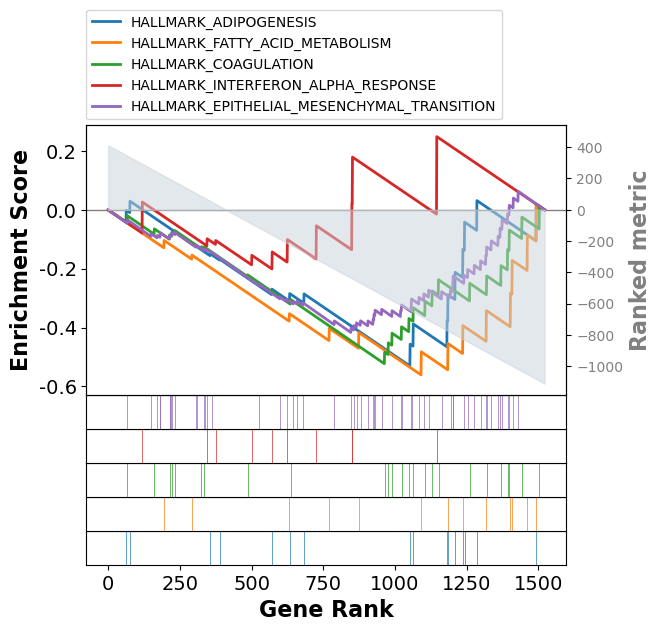

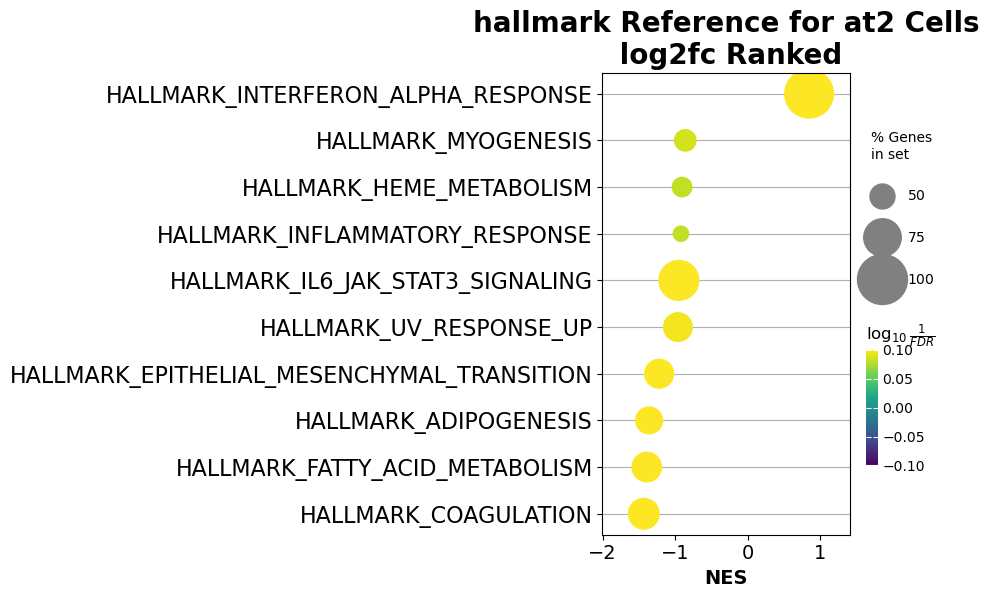

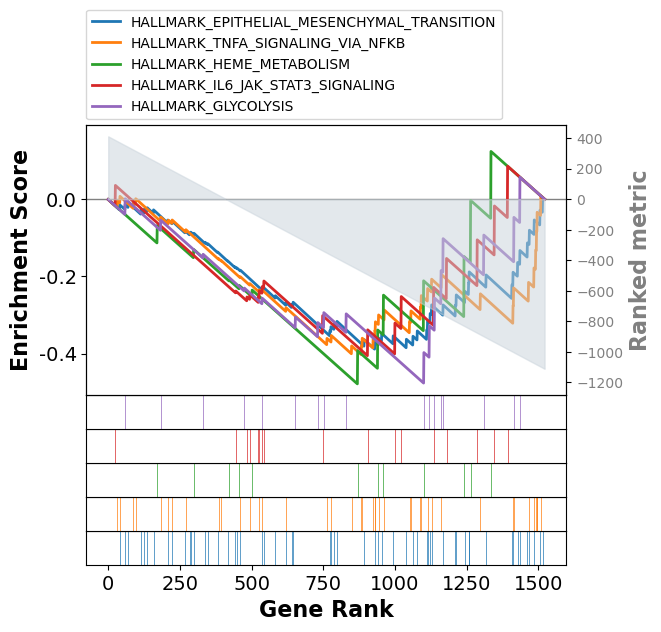

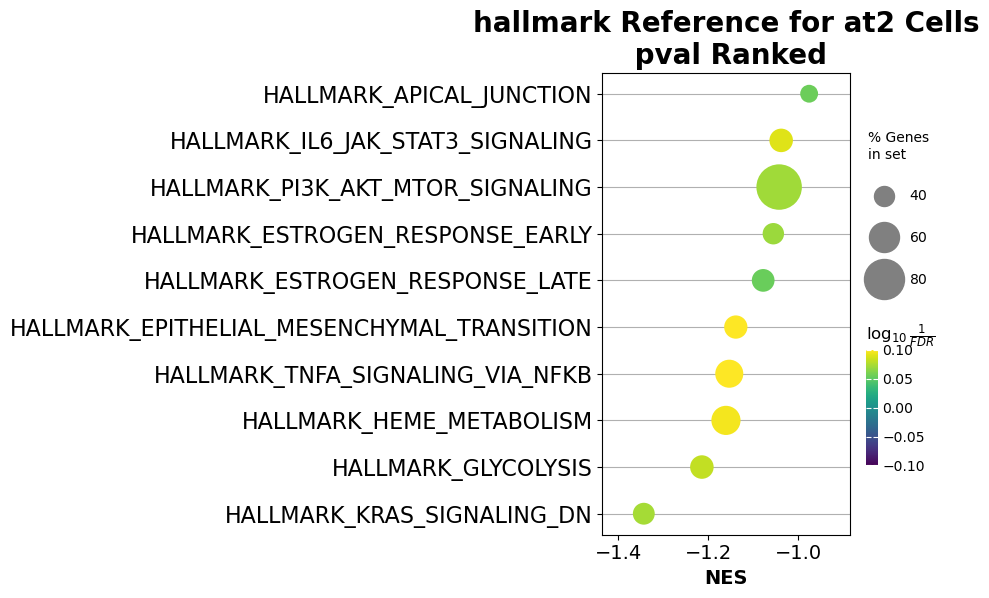

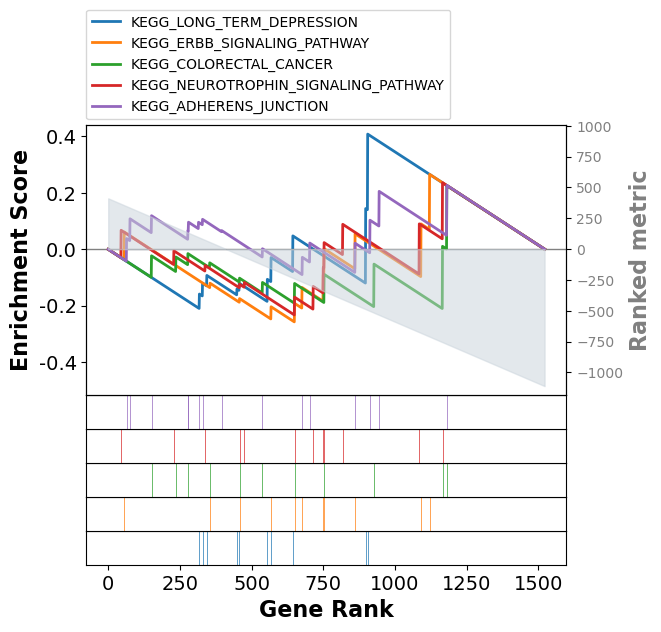

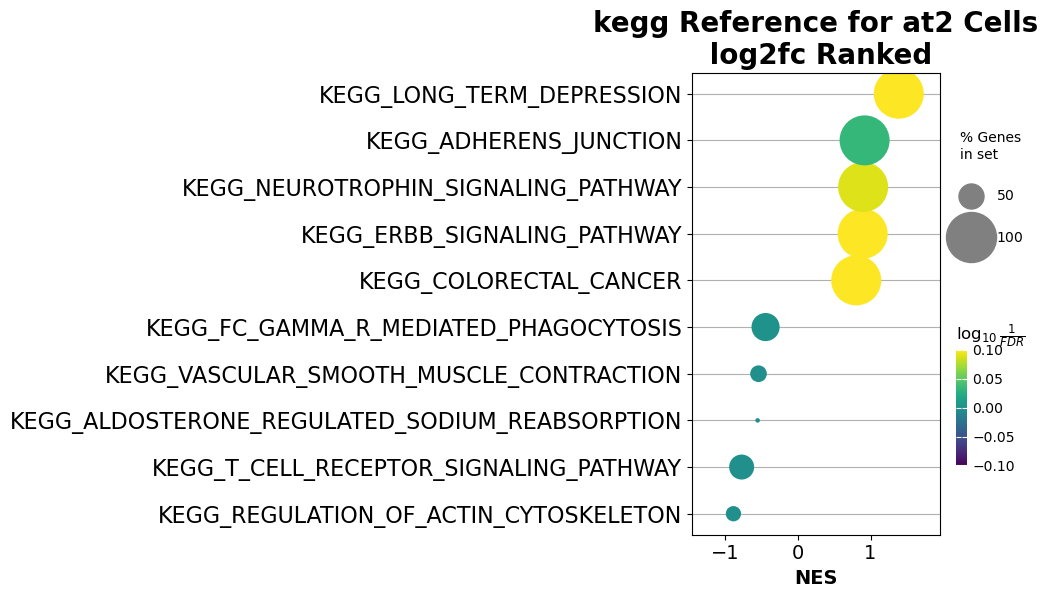

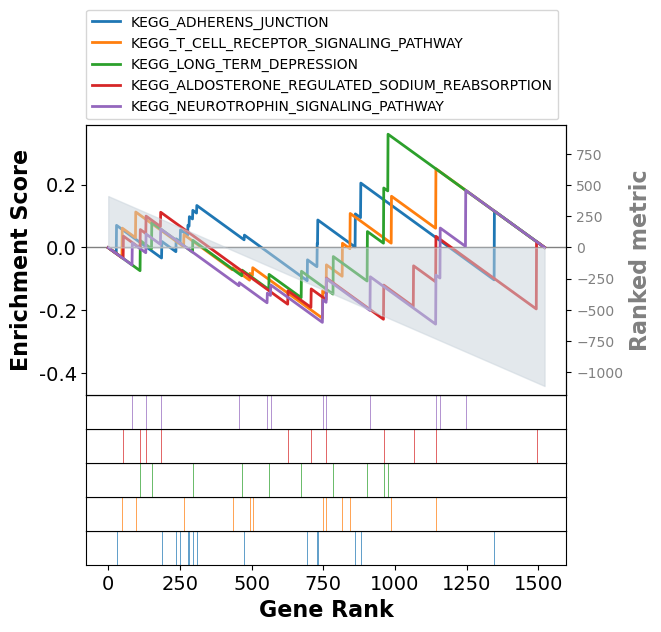

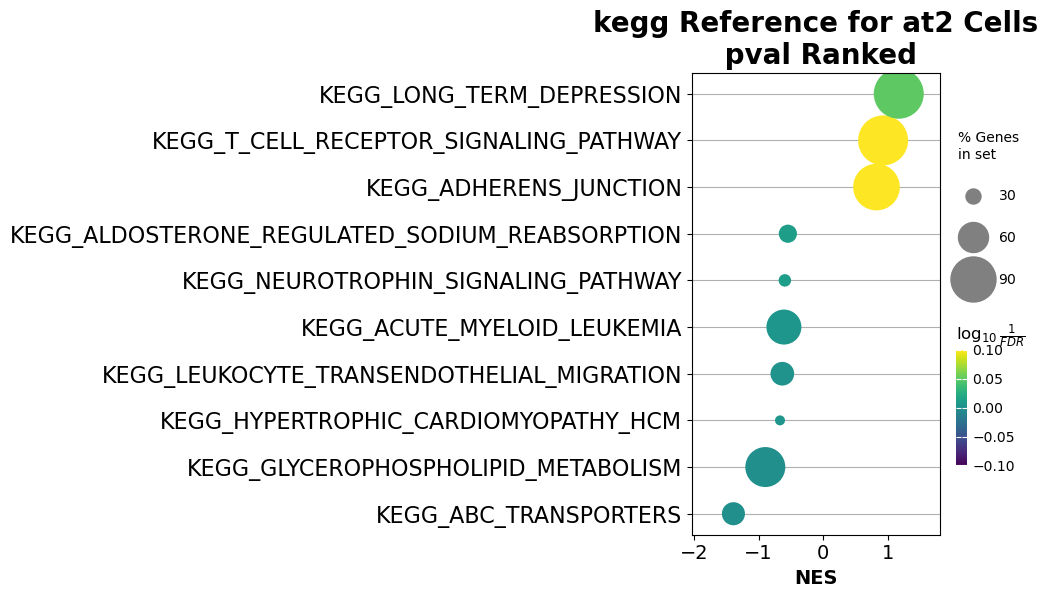

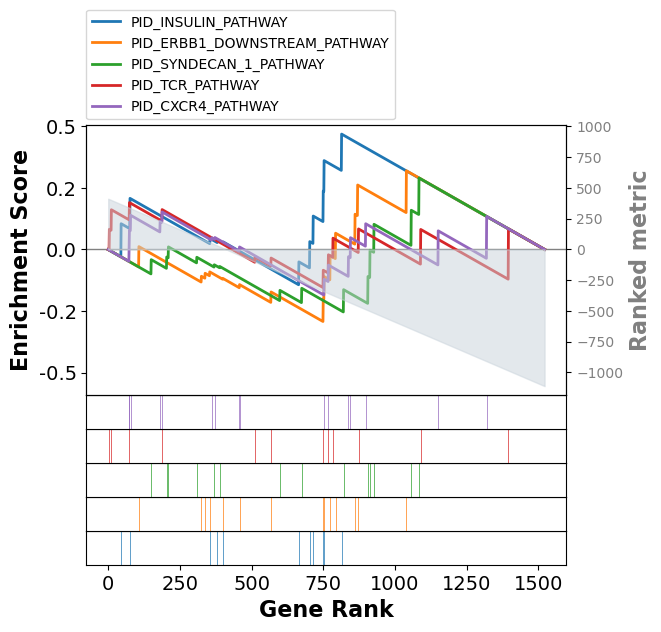

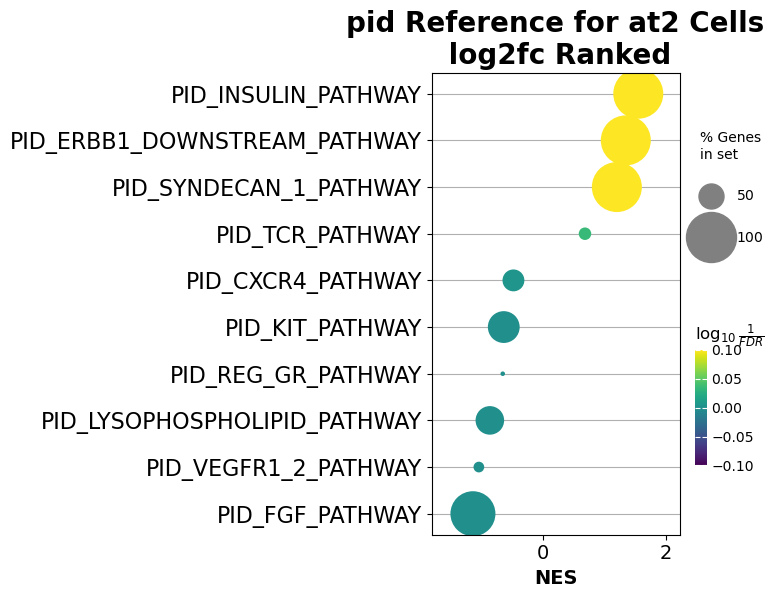

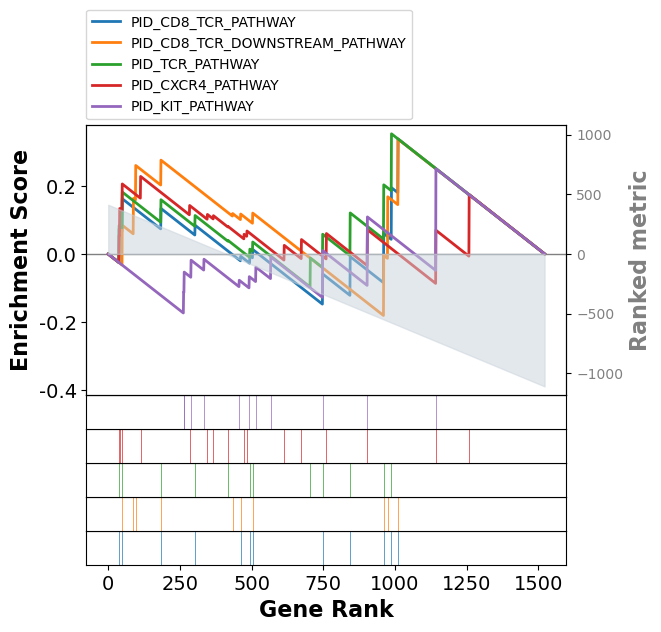

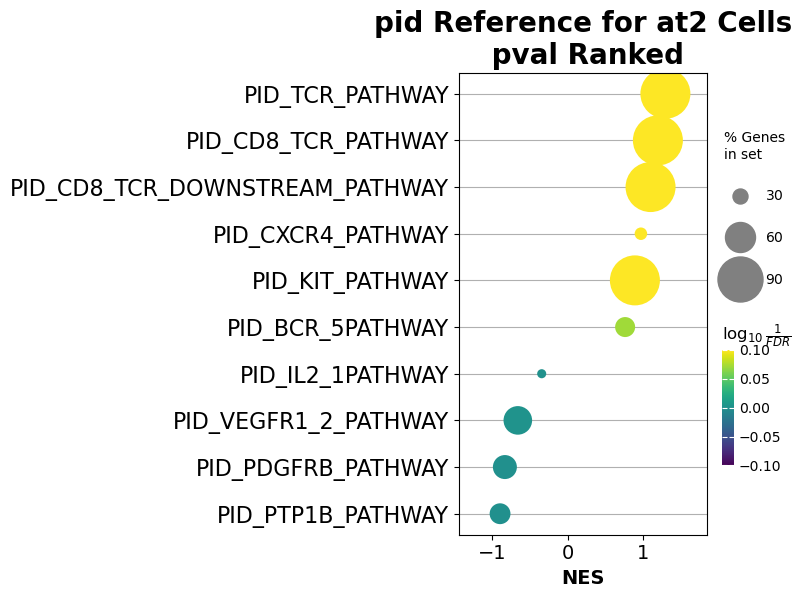

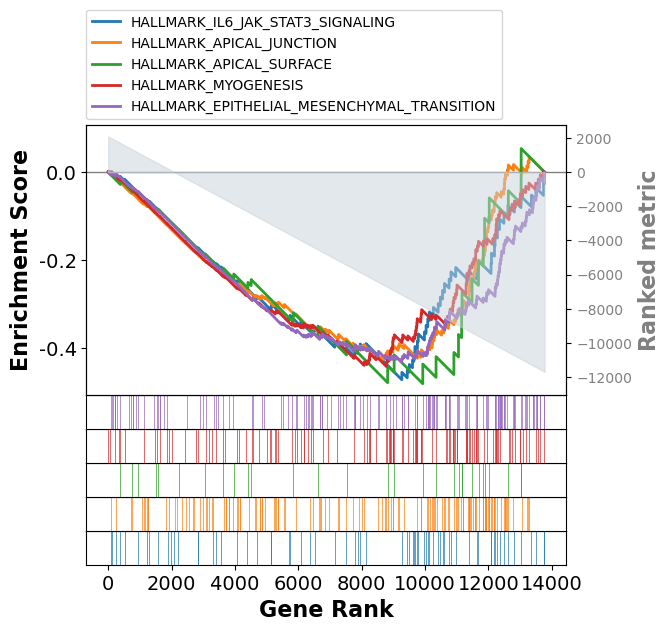

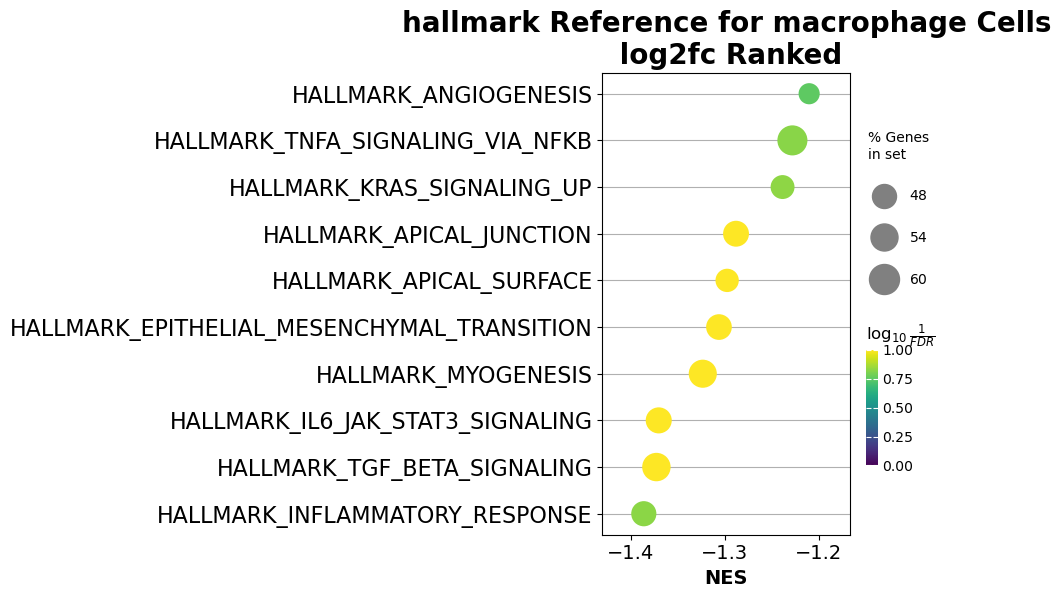

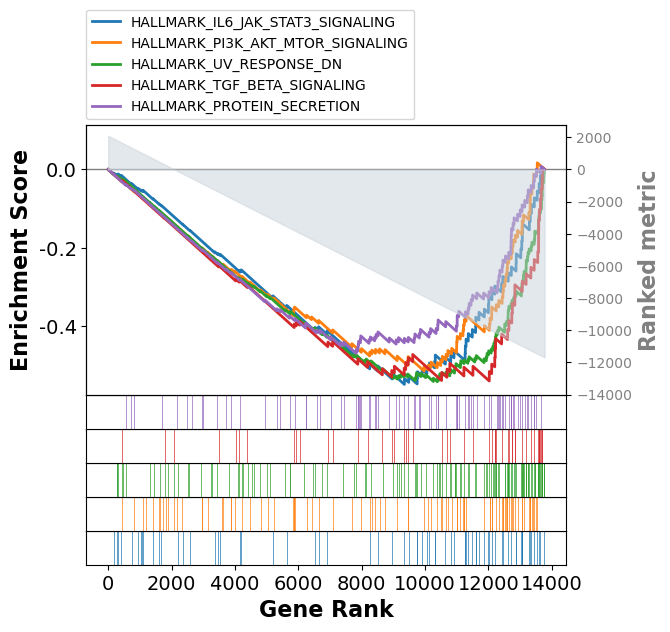

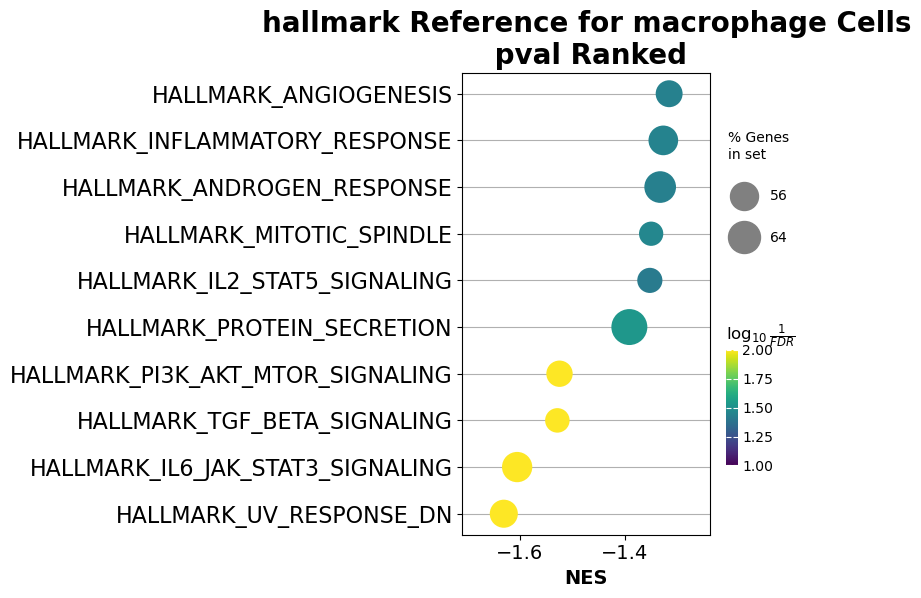

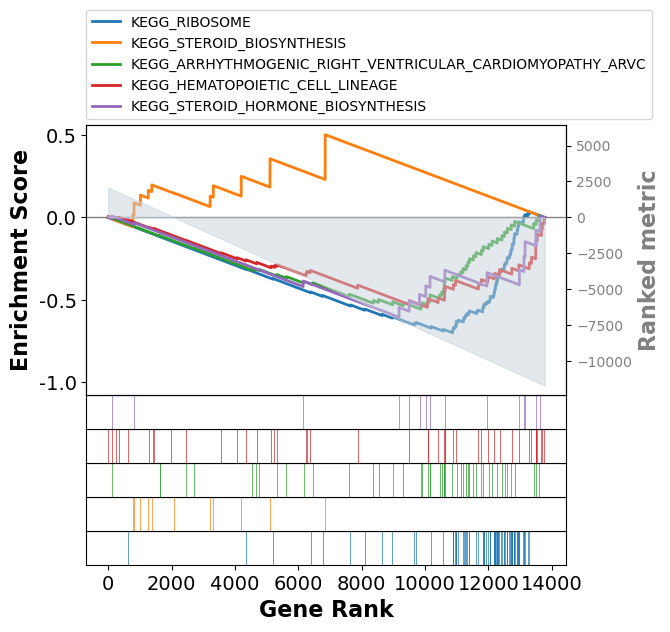

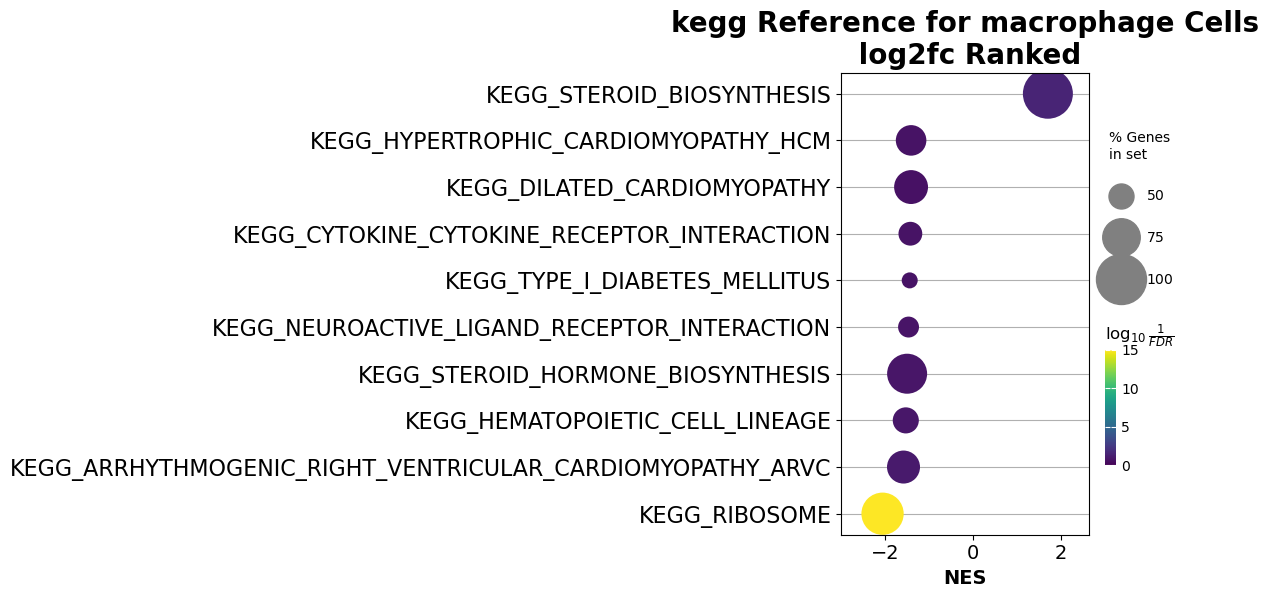

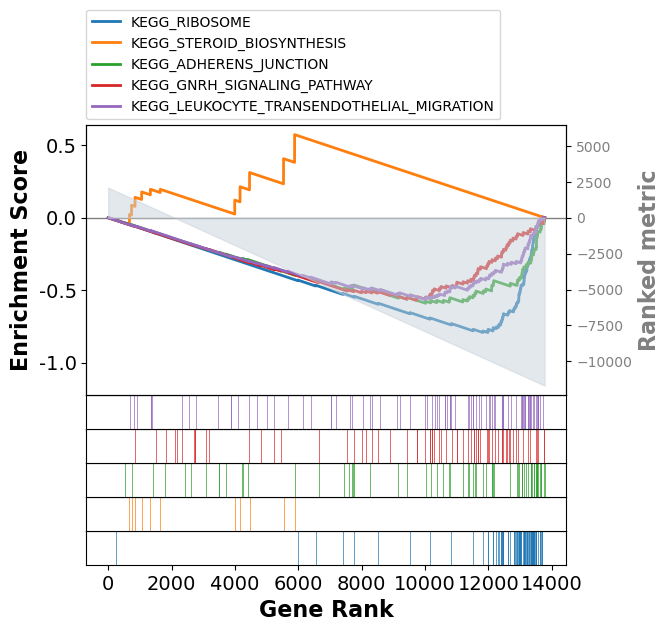

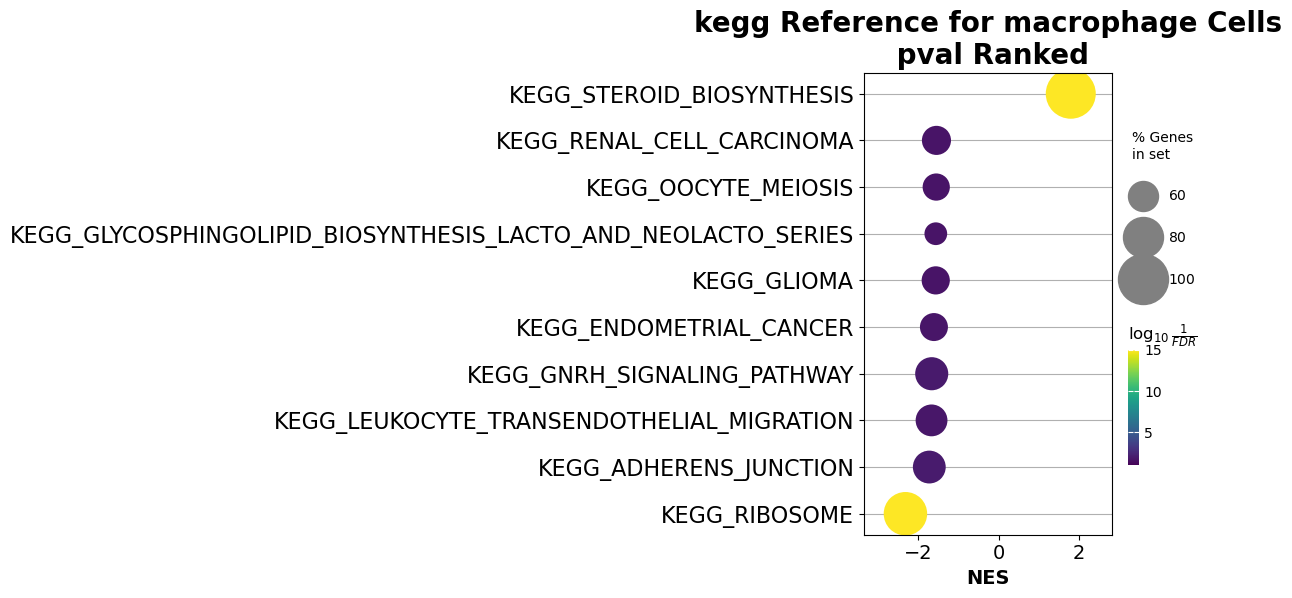

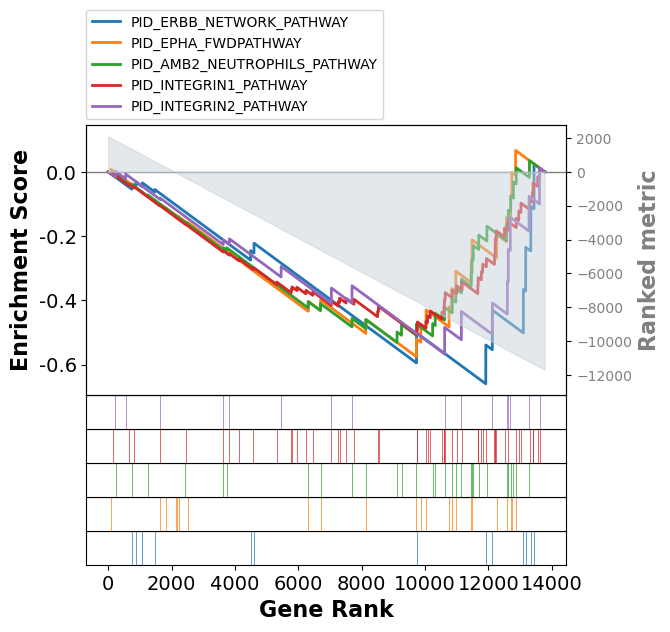

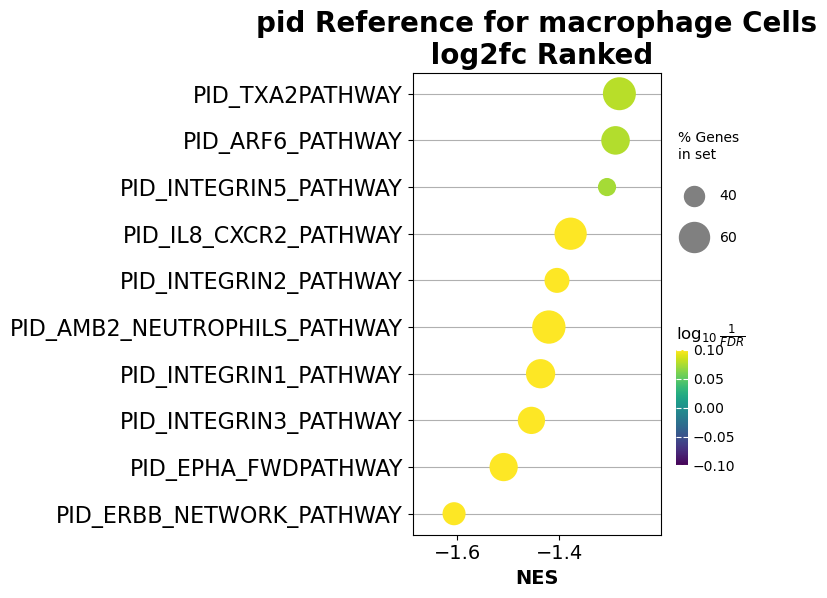

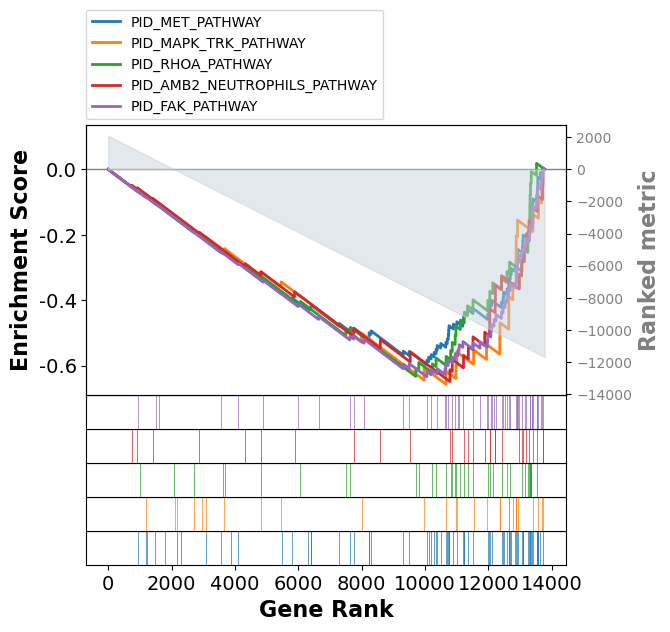

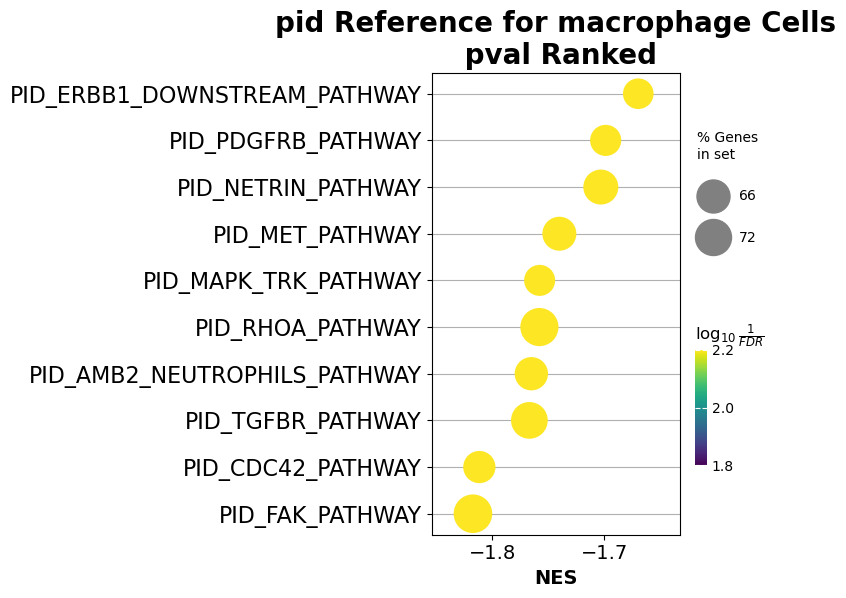

In [12]:
for cell in cell_types:
    print(cell)
    for database in databases:
        print(database)
        for ranking in rankings:
            print(ranking)
            # Prerank
            if cell == "at2":
                prerank_list = de_genes_at2.sort_values(f"{ranking}_ranks", ascending = False)
            elif cell == "macrophage":
                prerank_list = de_genes_macs.sort_values(f"{ranking}_ranks", ascending = False)
            else:
                print(f"Need to provide differential expression for selected cell type: {cell}")
            prerank_list[["gene_symbol", f"{ranking}_ranks"]]
            # Select pathway database reference
            if database == "hallmark":
                gmt = msig.get_gmt(category = "h.all", dbver = "2025.1.Hs")
            elif database == "kegg":
                gmt = msig.get_gmt(category = "c2.cp.kegg_legacy", dbver = "2025.1.Hs")
            elif database == "pid":
                gmt = msig.get_gmt(category = "c2.cp.pid", dbver = "2025.1.Hs")
            else:
                print("Error with pathway database selection")           
            # Run GSEA
            pre_res = gp.prerank(rnk = prerank_list[["gene_symbol", f"{ranking}_ranks"]], 
                                gene_sets = gmt,
                                threads = 4,
                                min_size = 10,
                                max_size = 500,
                                permutation_num = 1000, # reduce number to speed up testing
                                outdir = f"{project_dir}/output/09_gsea/{database}_{cell}_{ranking}_ranking", # don't write to disk
                                graph_num = 25,
                                format = "png",
                                verbose=True, # see what's going on behind the scenes
                                )
            gsea_sorted = pre_res.res2d.sort_values("FDR q-val", ascending=True)
            # Preview results
            print(gsea_sorted.head(5))
            # Swoosh plot
            terms = gsea_sorted.Term
            axs = pre_res.plot(terms=terms[0:5],
                            #legend_kws={'loc': (1.2, 0)}, # set the legend loc
                            show_ranking=True, # whether to show the second yaxis
                            figsize=(5,6)
                            )
            print(axs)
            # Dot plot
            ax = dotplot(gsea_sorted,
                        column="FDR q-val",
                        title=f"{database} Reference for {cell} Cells\n {ranking} Ranked",
                        cmap=plt.cm.viridis,
                        size=6, # adjust dot size
                        figsize=(4,6), cutoff=1, show_ring=False)
            print(ax)


at2
hallmark
log2fc


2025-07-23 12:14:38,988 [INFO] Parsing data files for GSEA.............................
2025-07-23 12:14:38,995 [INFO] 0017 gene_sets have been filtered out when max_size=500 and min_size=10
2025-07-23 12:14:38,996 [INFO] 0033 gene_sets used for further statistical testing.....
2025-07-23 12:14:38,996 [INFO] Start to run GSEA...Might take a while..................
2025-07-23 12:14:39,343 [INFO] Congratulations. GSEApy runs successfully................



pval


2025-07-23 12:14:40,465 [INFO] Parsing data files for GSEA.............................
2025-07-23 12:14:40,471 [INFO] 0017 gene_sets have been filtered out when max_size=500 and min_size=10
2025-07-23 12:14:40,472 [INFO] 0033 gene_sets used for further statistical testing.....
2025-07-23 12:14:40,473 [INFO] Start to run GSEA...Might take a while..................
2025-07-23 12:14:40,708 [INFO] Congratulations. GSEApy runs successfully................



kegg
log2fc


...

      Name                                       Term        ES       NES  \
0  prerank                              KEGG_RIBOSOME -0.792824  -2.32153   
1  prerank                  KEGG_STEROID_BIOSYNTHESIS  0.573276  1.790865   
2  prerank                     KEGG_ADHERENS_JUNCTION -0.591258 -1.728027   
4  prerank                KEGG_GNRH_SIGNALING_PATHWAY -0.571636 -1.667603   
3  prerank  KEGG_LEUKOCYTE_TRANSENDOTHELIAL_MIGRATION -0.566469 -1.672038   

  NOM p-val FDR q-val FWER p-val  Tag %  Gene %  \
0       0.0       0.0        0.0  73/84  13.01%   
1       0.0       0.0        0.0  11/11  42.72%   
2       0.0  0.009982       0.02  44/67  27.25%   
4       0.0  0.011479      0.046  47/71  29.35%   
3       0.0  0.014973      0.045  56/88  27.33%   

                                          Lead_genes  
0  RPL41;RPL11;RPS12;RPL10;RPLP1;RPL13A;RPS18;RPS...  
1  MSMO1;HSD17B7;DHCR24;CYP51A1;TM7SF2;LIPA;EBP;N...  
2  TCF7L2;PTPRM;TGFBR2;LMO7;CTNNA1;CTNNB1;FER;PTP...  
4  GNAQ;CA

2025-07-23 12:16:04,390 [INFO] Parsing data files for GSEA.............................
2025-07-23 12:16:04,409 [INFO] 0005 gene_sets have been filtered out when max_size=500 and min_size=10
2025-07-23 12:16:04,409 [INFO] 0191 gene_sets used for further statistical testing.....
2025-07-23 12:16:04,411 [INFO] Start to run GSEA...Might take a while..................
2025-07-23 12:16:15,119 [INFO] Congratulations. GSEApy runs successfully................



pval


2025-07-23 12:16:16,251 [INFO] Parsing data files for GSEA.............................
2025-07-23 12:16:16,268 [INFO] 0005 gene_sets have been filtered out when max_size=500 and min_size=10
2025-07-23 12:16:16,269 [INFO] 0191 gene_sets used for further statistical testing.....
2025-07-23 12:16:16,269 [INFO] Start to run GSEA...Might take a while..................
2025-07-23 12:16:36,297 [INFO] Congratulations. GSEApy runs successfully................



      Name                          Term        ES       NES NOM p-val  \
6  prerank               PID_MET_PATHWAY -0.597268 -1.740187       0.0   
5  prerank          PID_MAPK_TRK_PATHWAY -0.657426 -1.757775       0.0   
4  prerank              PID_RHOA_PATHWAY -0.633141 -1.757984       0.0   
3  prerank  PID_AMB2_NEUTROPHILS_PATHWAY -0.648729 -1.765172       0.0   
0  prerank               PID_FAK_PATHWAY -0.634248 -1.817258       0.0   

  FDR q-val FWER p-val  Tag %  Gene %  \
6  0.001864      0.013  51/75  27.00%   
5  0.002007      0.012  18/29  22.59%   
4  0.002408      0.012  29/38  29.52%   
3   0.00276      0.011  20/30  21.70%   
0   0.00301      0.003  44/57  27.00%   

                                          Lead_genes  
6  RAP1B;CTNNA1;NUMB;CTNNB1;GRB2;PTPRJ;RAP1A;MET;...  
5  RAP1B;BRAF;MAPK14;RAP1A;MAPK1;MAP2K5;MAPKAPK2;...  
4  VCL;PPP1R12A;LIMK2;DIAPH1;PKN2;PIP5K1B;ROCK1;M...  
3  RAP1B;LYN;HCK;RAP1A;ROCK1;FYN;LRP1;NFKB1;YES1;...  
0  RAP1B;BRAF;ASAP1;RASA1;GRB2;VC

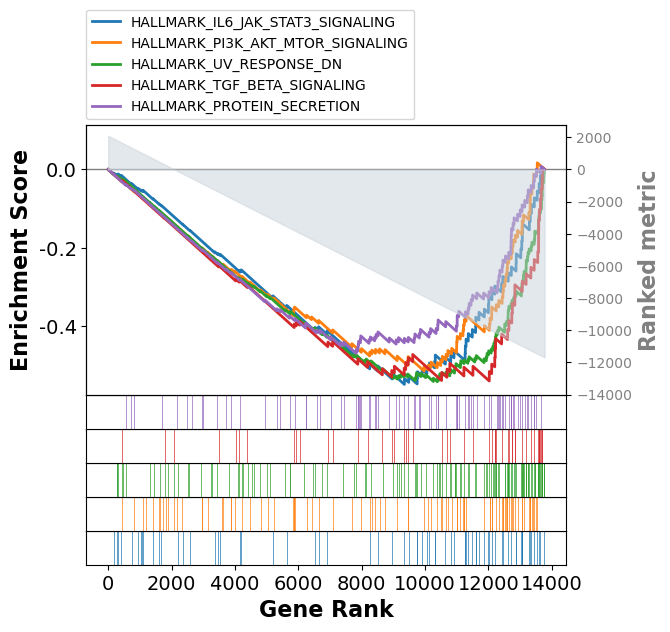

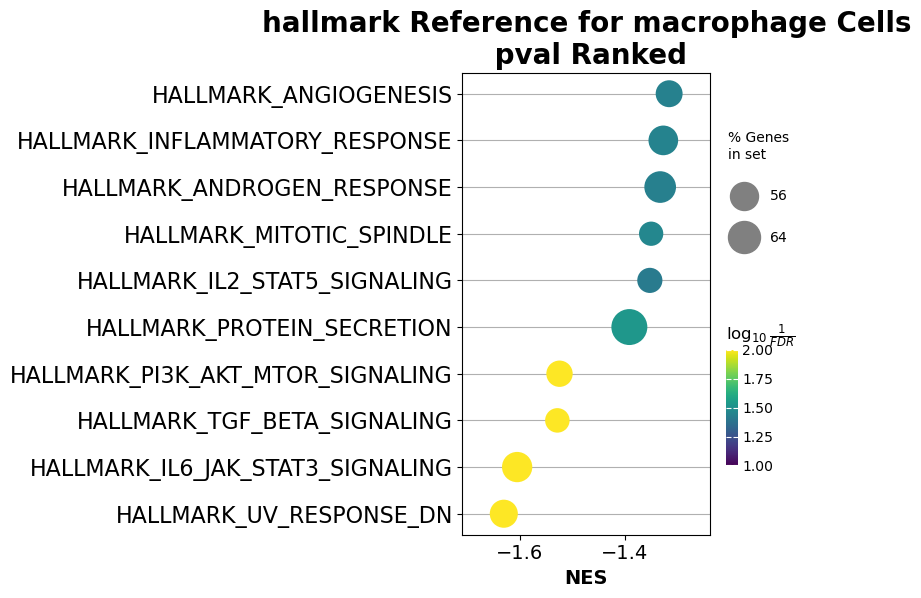

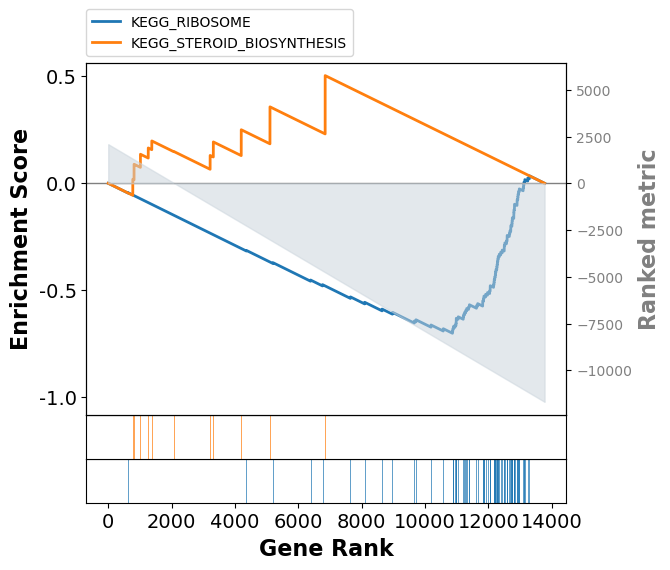

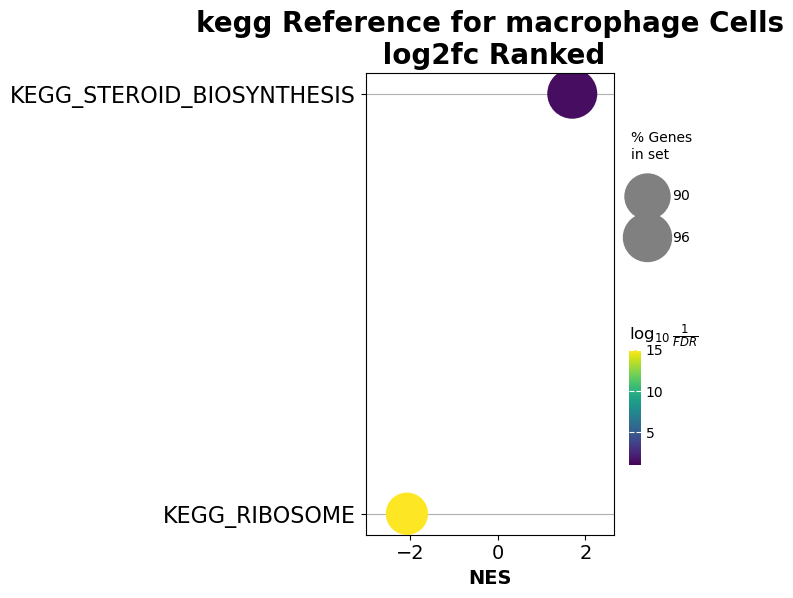

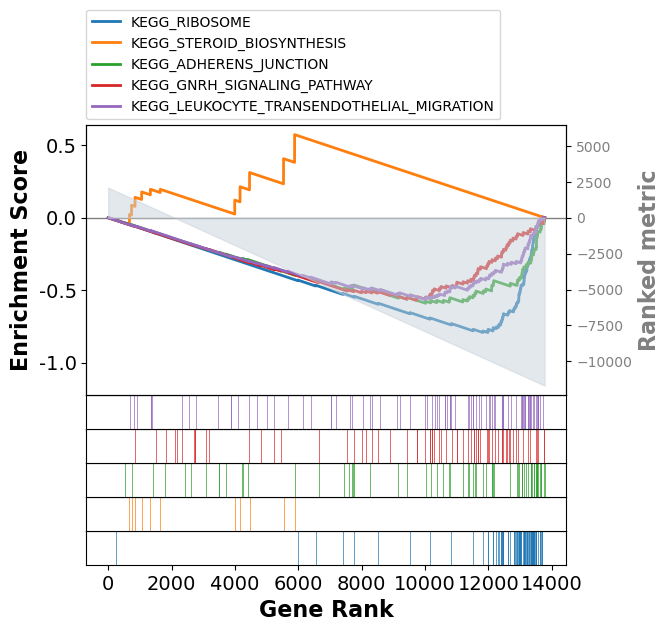

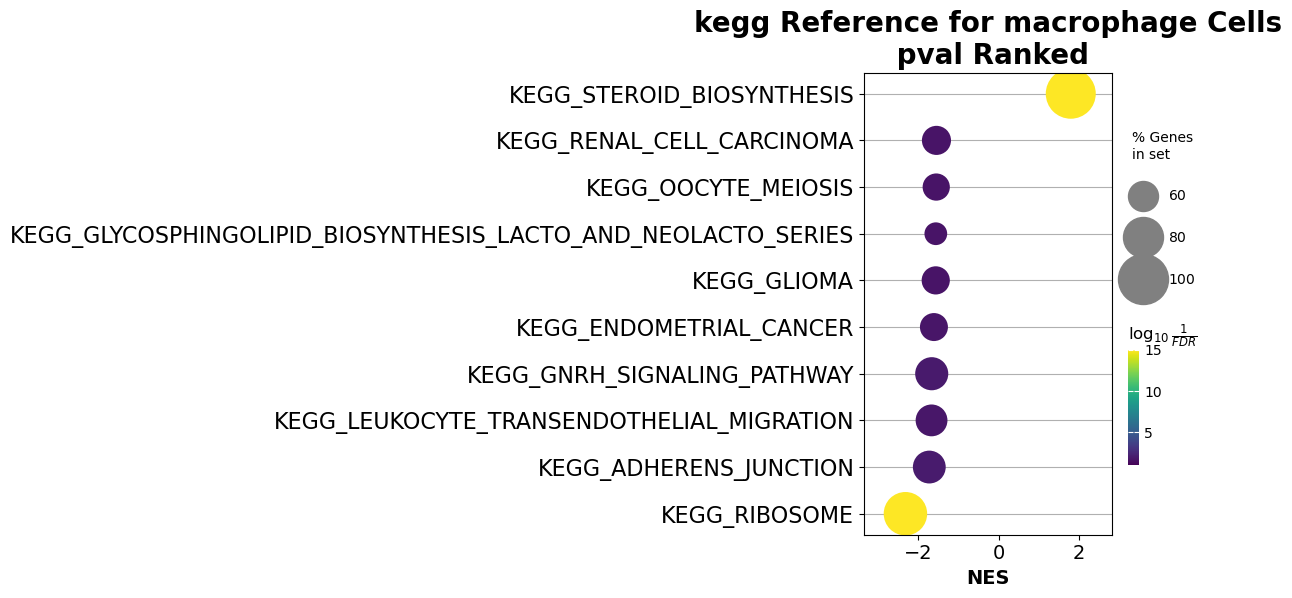

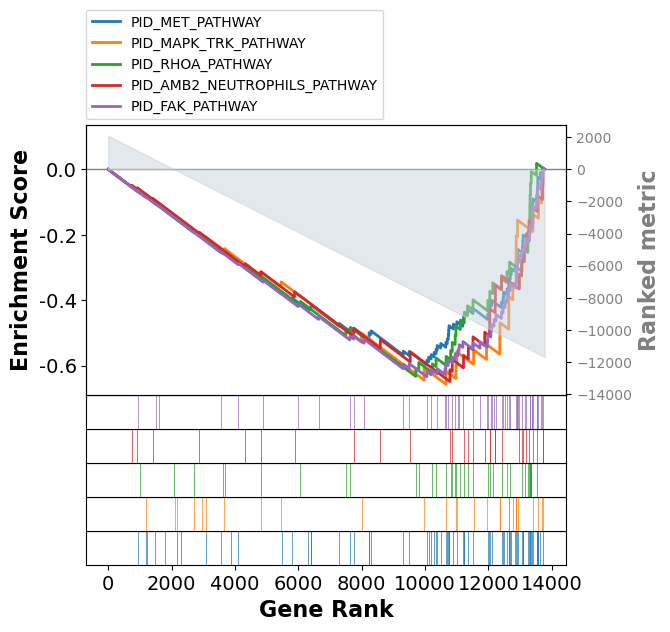

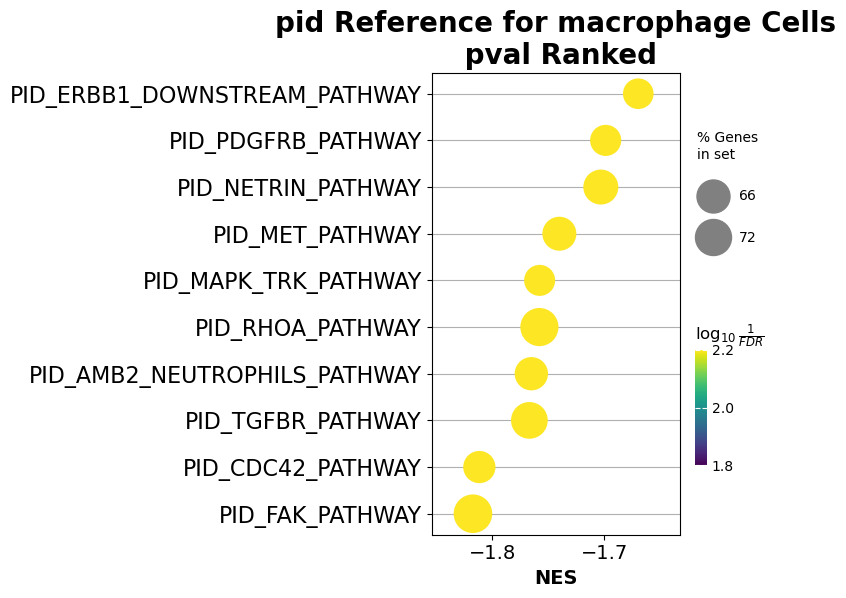

In [15]:
for cell in cell_types:
    print(cell)
    for database in databases:
        print(database)
        for ranking in rankings:
            print(ranking)
            # Prerank
            if cell == "at2":
                prerank_list = de_genes_at2.sort_values(f"{ranking}_ranks", ascending = False)
            elif cell == "macrophage":
                prerank_list = de_genes_macs.sort_values(f"{ranking}_ranks", ascending = False)
            else:
                print(f"Need to provide differential expression for selected cell type: {cell}")
            prerank_list[["gene_symbol", f"{ranking}_ranks"]]
            # Select pathway database reference
            if database == "hallmark":
                gmt = msig.get_gmt(category = "h.all", dbver = "2025.1.Hs")
            elif database == "kegg":
                gmt = msig.get_gmt(category = "c2.cp.kegg_legacy", dbver = "2025.1.Hs")
            elif database == "pid":
                gmt = msig.get_gmt(category = "c2.cp.pid", dbver = "2025.1.Hs")
            else:
                print("Error with pathway database selection")           
            # Run GSEA
            pre_res = gp.prerank(rnk = prerank_list[["gene_symbol", f"{ranking}_ranks"]], 
                                gene_sets = gmt,
                                threads = 4,
                                min_size = 10,
                                max_size = 500,
                                permutation_num = 1000, # reduce number to speed up testing
                                outdir = f"{project_dir}/output/09_gsea/{database}_{cell}_{ranking}_ranking", # don't write to disk
                                graph_num = 25,
                                format = "png",
                                verbose=True, # see what's going on behind the scenes
                                )
            gsea_sorted = pre_res.res2d.sort_values("FDR q-val", ascending=True)
            sig_res = gsea_sorted[gsea_sorted["FDR q-val"] < 0.05]
            # Preview results
            if len(sig_res) > 0:
                print(sig_res.head(5))
                # Swoosh plot
                terms = sig_res.Term
                axs = pre_res.plot(terms=terms[0:5],
                                #legend_kws={'loc': (1.2, 0)}, # set the legend loc
                                show_ranking=True, # whether to show the second yaxis
                                figsize=(5,6)
                                )
                print(axs)
                # Dot plot
                ax = dotplot(sig_res,
                            column="FDR q-val",
                            title=f"{database} Reference for {cell} Cells\n {ranking} Ranked",
                            cmap=plt.cm.viridis,
                            size=6, # adjust dot size
                            figsize=(4,6), cutoff=1, show_ring=False)
                print(ax)